In [2]:
from pathlib import Path
from scaleagdata_vito.openeo.extraction_utils import (
    check_job_status,
    get_succeeded_job_details,
    load_point_extractions,
    get_band_statistics,
    visualize_timeseries,
)
import geopandas as gpd
from loguru import logger

#### Assess data correctness before launching the OpenEO jobs 
You can run some checks on your input file to make sure they are suitable to run the extractions successfully. In particular, it is important to check the validity of the geometries and, ideally, to also have a column containing a unique id for each sample.

In case of invalid geometries, you will be provided with both the dataframe with the failing polygons to be fixed and the one with valid geometries.

In [ ]:
def check_unique_id(df_path, unique_id):
    df = gpd.read_file(df_path)
    if df[unique_id].nunique() != df.shape[0]:
        logger.info("IDs are not unique!")
        return df[df[unique_id].duplicated(keep=False)]
    else:
        logger.info("IDs are unique")
        return None

def check_valid_geometry(df):
    if isinstance(df, str):
        df = gpd.read_file(df)
    df_invalid = df[~df.geometry.is_valid]
    # Assessing wheather some invalid geometries are present
    if len(df_invalid) > 0:
        # 1) some invalid geometries are present. Attempt fixing them
        df['geometry'] = df.geometry.buffer(0)
        df_invalid = df[~df.geometry.is_valid]
        df_valid = df[df.geometry.is_valid]
        if len(df_invalid) > 0:
            # 2) Still some invalid geometries are present. Return them
            logger.info("Invalid geometries found! Returning invalid geometries")
            return df_invalid, df_valid
        else:
            # All geometries are now valid. Return fixed dataframe and empty dataframe for invalid geometries
            logger.info("Fixed some invalid geometries. All geometries are now valid")
            return gpd.GeoDataFrame(), df
    else:
        # All geometries are valid. Return empty dataframe for invalid geometries
        logger.info("All geometries are valid")
        return gpd.GeoDataFrame(), df

In [ ]:
input_file = ".../extraction_inputfile.geojson"
invalid_geom, valid_geom = check_valid_geometry(input_file)
non_unique_ids = check_unique_id(input_file, unique_id="Field_id")

2025-08-11 14:16:22.431 | INFO     | __main__:check_valid_geometry:30 - All geometries are valid
2025-08-11 14:16:22.459 | INFO     | __main__:check_unique_id:7 - IDs are unique


### Inspect OpenEO extractions

Once the extractions have been completed, we can inspect the job tracking dataframe to find out how many jobs were successfully completed.


In [3]:
extractions_name = "LPIS_Extractions_2024"
extraction_folder = Path(f"/projects/HEScaleAgData/timeseries_modelling/datasets/{extractions_name}/extractions/")  # Replace with your output folder path
# status_histogram = check_job_status(extraction_folder)
# succeeded_jobs = get_succeeded_job_details(extraction_folder)

We can do a more in-depth check of the extracted data by:

- manually inspecting a subset of the extracted data (`load_point_extractions` function)

- printing statistics for each individual band that was extracted (`get_band_statistics` function)

- visualizing time series for a specified sample id (`visualize_timeseries` function)

NOTE: keep in mind when inspecting the results that nodata value = 0

In [5]:
gdf = load_point_extractions(
    extractions_dir=Path(extraction_folder),
    subset=True,
)
stats_df = get_band_statistics(gdf)

2025-12-10 10:13:05.939 | INFO     | scaleagdata_vito.openeo.extraction_utils:load_point_extractions:166 - Found 696 geoparquet files in /projects/HEScaleAgData/timeseries_modelling/datasets/LPIS_Extractions_2024/extractions


+---------------+------------+--------+--------+--------+-------+---------------+------------+
| band          |   %_nodata |    min |    max |   mean |   std | start_datae   | end_date   |
|---------------+------------+--------+--------+--------+-------+---------------+------------|
| S2-L2A-B02    |      44.09 |   0    |   0.37 |   0.06 |  0.04 | 2023-10-01    | 2025-05-31 |
| S2-L2A-B03    |      44.09 |   0.01 |   0.41 |   0.08 |  0.03 | 2023-10-01    | 2025-05-31 |
| S2-L2A-B04    |      44.09 |   0.01 |   0.45 |   0.08 |  0.05 | 2023-10-01    | 2025-05-31 |
| S2-L2A-B05    |      44.09 |   0.03 |   0.49 |   0.13 |  0.04 | 2023-10-01    | 2025-05-31 |
| S2-L2A-B06    |      44.09 |   0.04 |   0.68 |   0.27 |  0.14 | 2023-10-01    | 2025-05-31 |
| S2-L2A-B07    |      44.09 |   0.04 |   0.79 |   0.32 |  0.18 | 2023-10-01    | 2025-05-31 |
| S2-L2A-B08    |      44.09 |   0.05 |   0.84 |   0.34 |  0.18 | 2023-10-01    | 2025-05-31 |
| S2-L2A-B8A    |      44.09 |   0.06 |   0.81 |  

In [6]:
gdf.sample_id.unique()

array(['1907102436-444247-42', '1907102436-444247-45',
       '1907102436-444247-46', '1907102436-444247-47',
       '1907102436-444247-48', '1907102436-444247-49',
       '1907102436-444247-52', '1907102436-444247-53',
       '1907102436-444247-54', '1907102436-444247-55',
       '1907102436-444247-56', '1907102436-444247-57',
       '1907102436-444247-60', '1907102436-444247-61',
       '1907102436-444247-62', '1907102436-444247-63',
       '1907102436-444247-64', '1907102436-444247-67',
       '1907102436-444247-68', '1907102436-444247-69',
       '1907102436-444247-70', '1907102436-444247-71',
       '1907102436-444247-72', '1907102436-444247-75',
       '1907102436-444247-76', '1907102436-444247-77',
       '1907102436-444247-78', '1907102436-444247-80',
       '1907102436-444247-81', '1907102436-444247-82',
       '1907102436-444247-83', '1907102436-444247-84',
       '1907102436-444247-88', '1907102436-444247-90',
       '1907102436-444247-91', '1907102436-444247-93',
       '19

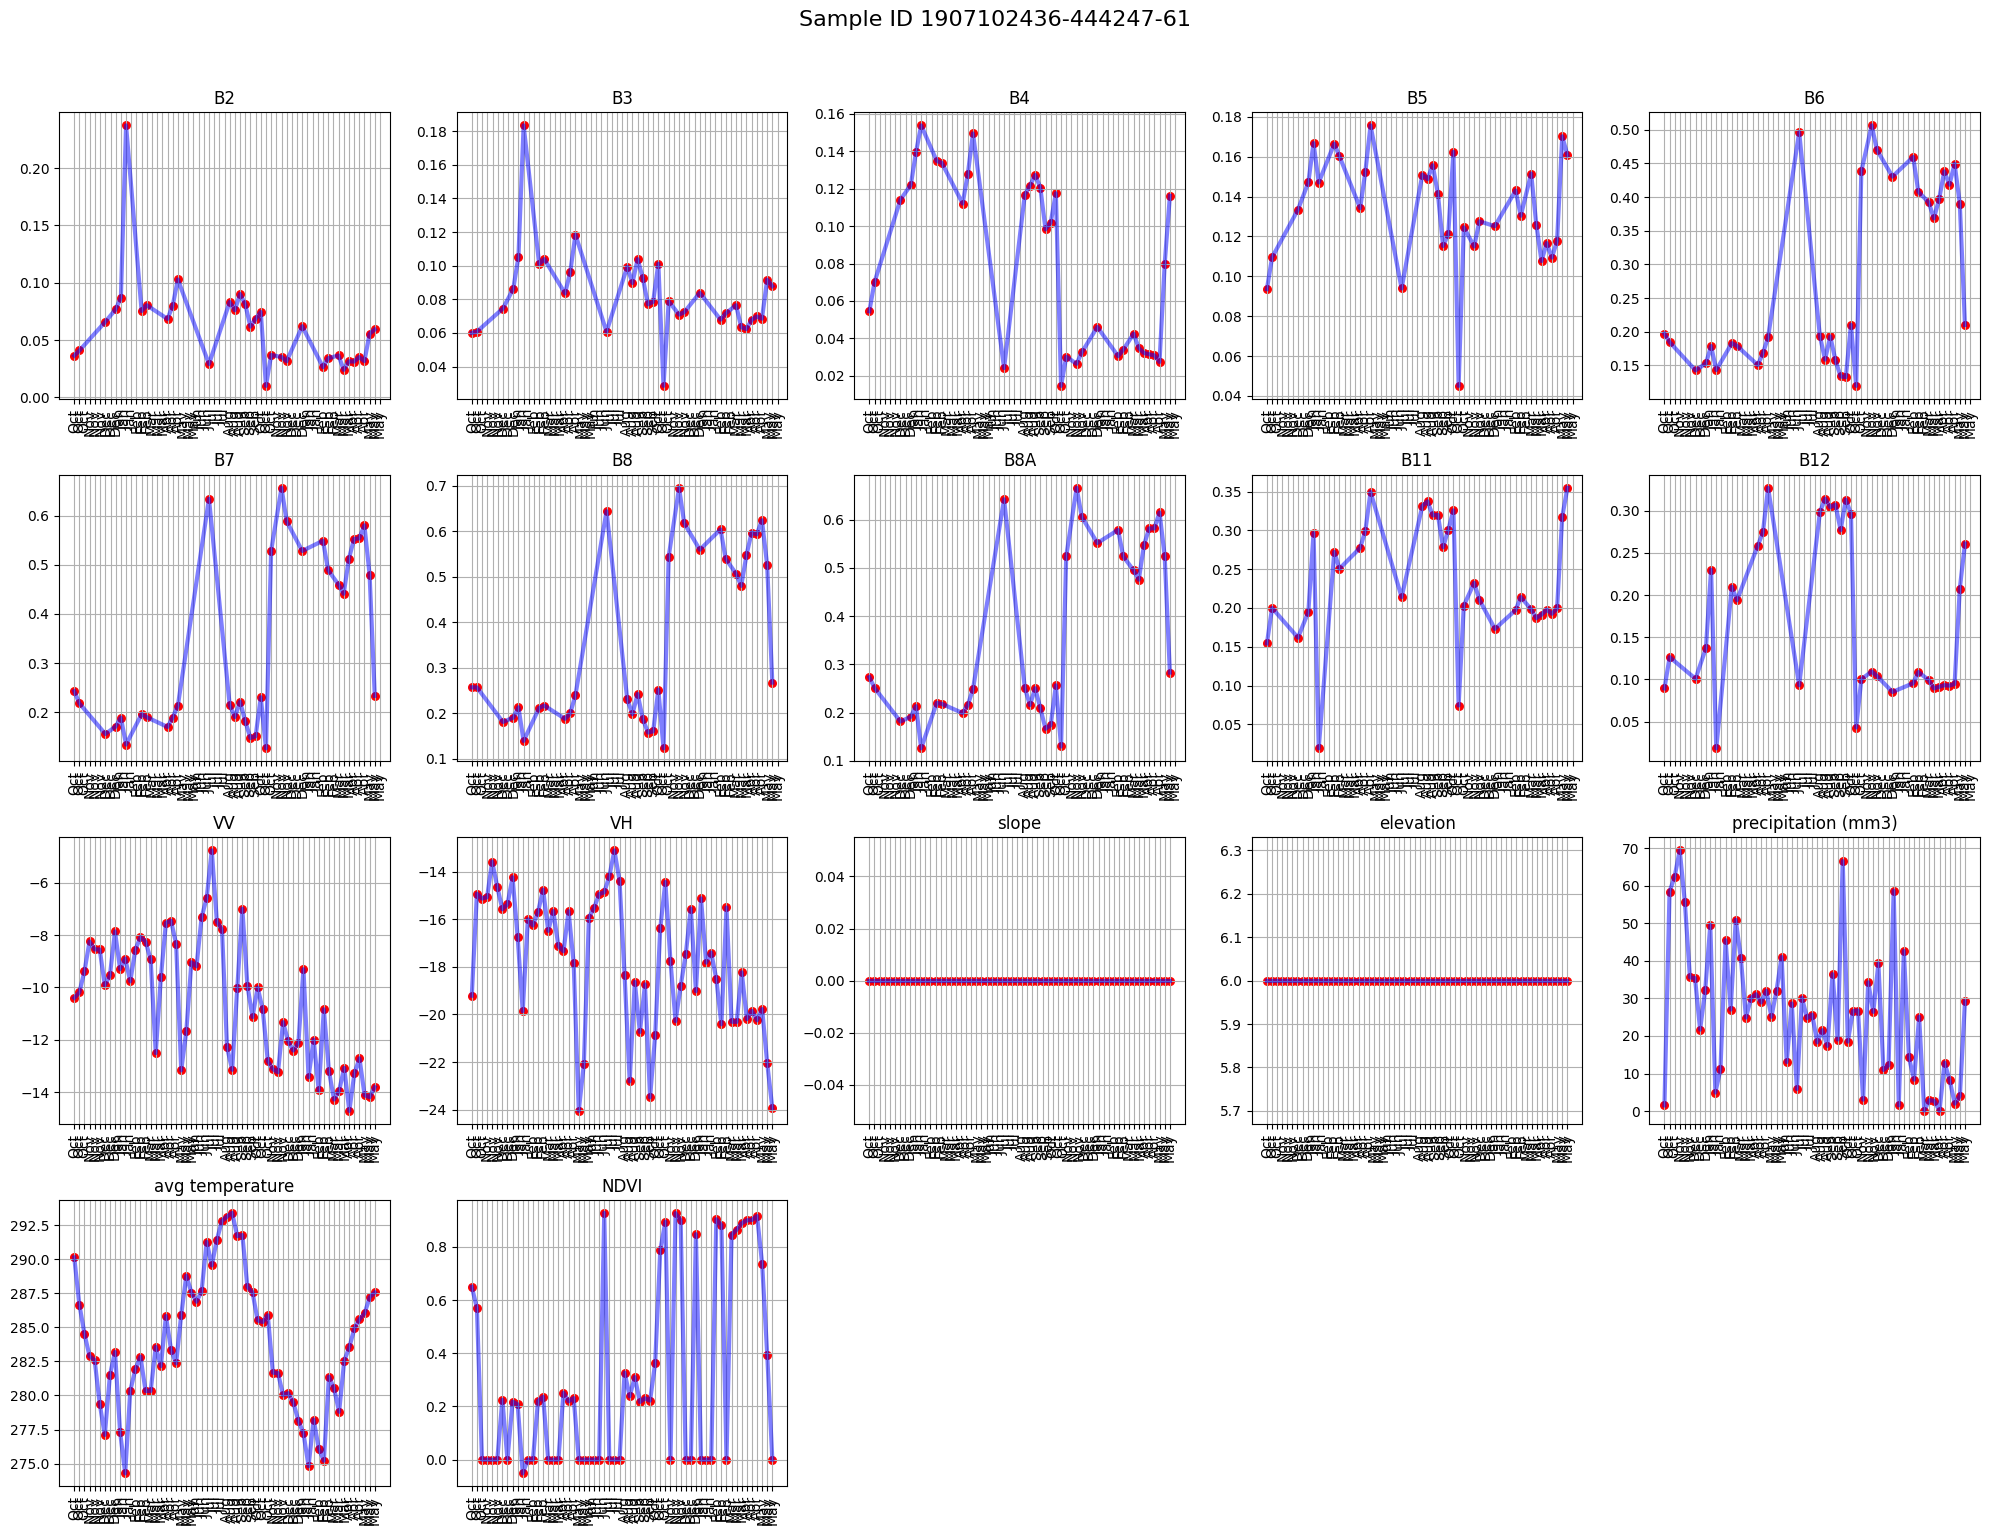

In [9]:
visualize_timeseries(gdf, sample_id="1907102436-444247-61")

In [1]:
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.presto.presto_df import load_dataset
from pathlib import Path


extractions_name = "LPIS_Extractions_2024"
p = f"/projects/HEScaleAgData/timeseries_modelling/datasets/{extractions_name}/extractions/"

# load extracted dataset
target_name = "median_yield"
composite_window = "dekad"
window_of_interest = ["2024-04-01", "2024-10-31"]
df = load_dataset(
    files_root_dir=p,
    window_of_interest=window_of_interest,
    no_data_value=65535,
    composite_window=composite_window,
)

  0%|          | 0/696 [00:00<?, ?it/s]/home/vito/millig/gio/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:724: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["start_date"] = window_of_interest[0]
/home/vito/millig/gio/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:725: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["end_date"] = window_of_interest[1]
  0%|          | 1/696 [00:00<02:53,  4.01it/s]/home/vito/millig/gio/scaleag-vito/src/scaleagdata_vito/presto/presto_df.p

In [20]:
from sklearn.model_selection import train_test_split

# Group by parentname and get the median_yield for each group
parent_groups = df.groupby('parentname').agg({
    'median_yield': 'median',
    'sample_id': 'count'
}).rename(columns={'sample_id': 'count'})

# Create bins for stratification based on the parent group's median yield
parent_groups['yield_bin'] = pd.cut(parent_groups['median_yield'], bins=50, labels=False, duplicates='drop')

# Filter out yield bins with less than 3 samples to avoid stratification issues
bin_counts = parent_groups['yield_bin'].value_counts()
valid_bins = bin_counts[bin_counts >= 3].index
parent_groups_filtered = parent_groups[parent_groups['yield_bin'].isin(valid_bins)]

print(f"Original parent groups: {len(parent_groups)}")
print(f"After filtering bins with <3 samples: {len(parent_groups_filtered)}")
print(f"Removed {len(parent_groups) - len(parent_groups_filtered)} parent groups")

# Get unique parentnames as our splitting units (from filtered data)
parentnames = parent_groups_filtered.index.tolist()
yield_bins = parent_groups_filtered['yield_bin'].values

# First split: 80% train, 20% temp (for val and test)
train_parents, temp_parents = train_test_split(
    parentnames,
    train_size=0.8,
    stratify=yield_bins,
    random_state=42
)

# Get yield bins for temp parents and check if they still have enough samples for stratification
temp_bins = parent_groups_filtered.loc[temp_parents, 'yield_bin'].values
temp_bin_counts = pd.Series(temp_bins).value_counts()

# Check if any bin in temp set has less than 2 samples (minimum for stratification)
if (temp_bin_counts < 2).any():
    print("Warning: Some bins in temp set have <2 samples. Using random split instead of stratified split for val/test.")
    # Second split: split temp randomly into 50-50 for val and test
    val_parents, test_parents = train_test_split(
        temp_parents,
        train_size=0.5,
        random_state=42
    )
else:
    # Second split: split temp into 50-50 for val and test with stratification
    val_parents, test_parents = train_test_split(
        temp_parents,
        train_size=0.5,
        stratify=temp_bins,
        random_state=42
    )

# Create the final datasets by filtering on parentname
df_train = df[df['parentname'].isin(train_parents)]
df_val = df[df['parentname'].isin(val_parents)]
df_test = df[df['parentname'].isin(test_parents)]

print(f"Train set size: {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation set size: {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test set size: {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")

# Verify no parentname overlap
assert len(set(df_train['parentname']) & set(df_val['parentname'])) == 0
assert len(set(df_train['parentname']) & set(df_test['parentname'])) == 0
assert len(set(df_val['parentname']) & set(df_test['parentname'])) == 0
print("✓ No parentname overlap between splits")

Original parent groups: 2326
After filtering bins with <3 samples: 2320
Removed 6 parent groups
Train set size: 137219 (79.7%)
Validation set size: 16151 (9.4%)
Test set size: 18719 (10.9%)
✓ No parentname overlap between splits


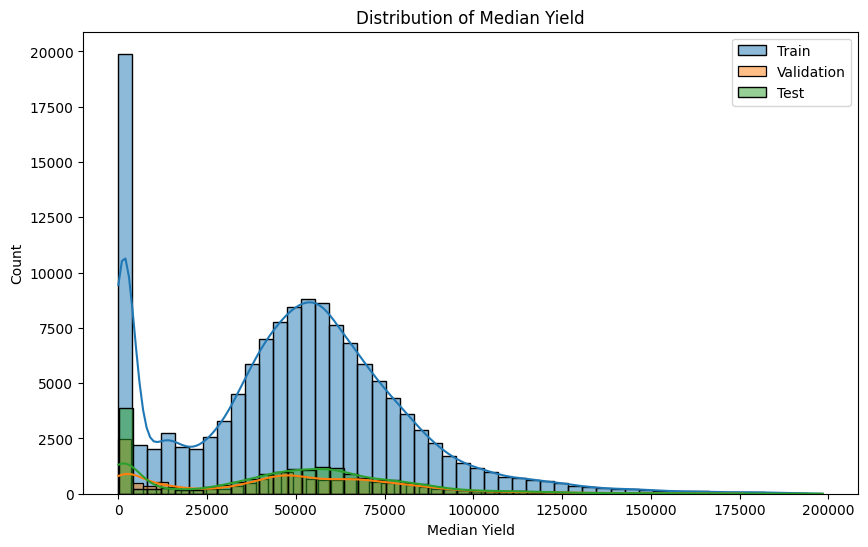

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_train, x='median_yield', bins=50, kde=True, label='Train')
sns.histplot(data=df_val, x='median_yield', bins=50, kde=True, label='Validation')
sns.histplot(data=df_test, x='median_yield', bins=50, kde=True, label='Test')
plt.title('Distribution of Median Yield')
plt.xlabel('Median Yield')
plt.ylabel('Count')
plt.legend()
plt.show()

In [25]:
woi_tag = f"{window_of_interest[0].replace('-', '')}-{window_of_interest[1].replace('-', '')}"
df_train.to_parquet(f"/projects/HEScaleAgData/reference_datasets/LPIS_Extractions_2024/df_train_{woi_tag}.parquet")
df_val.to_parquet(f"/projects/HEScaleAgData/reference_datasets/LPIS_Extractions_2024/df_val_{woi_tag}.parquet")
df_test.to_parquet(f"/projects/HEScaleAgData/reference_datasets/LPIS_Extractions_2024/df_test_{woi_tag}.parquet")


In [14]:
import pandas as pd

window_of_interest = ["2024-04-01", "2024-10-31"]
woi_tag = f"{window_of_interest[0].replace('-', '')}-{window_of_interest[1].replace('-', '')}"
df_train = pd.read_parquet(f"/projects/HEScaleAgData/reference_datasets/LPIS_Extractions_2024/df_train_{woi_tag}.parquet")
df_val = pd.read_parquet(f"/projects/HEScaleAgData/reference_datasets/LPIS_Extractions_2024/df_val_{woi_tag}.parquet")
df_test = pd.read_parquet(f"/projects/HEScaleAgData/reference_datasets/LPIS_Extractions_2024/df_test_{woi_tag}.parquet")

In [3]:
df_train.median_yield.mean(), df_train.median_yield.std()

(49240.03866173673, 31749.420960241037)

In [4]:
df_test.median_yield.mean(), df_test.median_yield.std()

(47283.09633549311, 33224.524534780954)

In [5]:
df_val.median_yield.mean(), df_val.median_yield.std()

(47416.182115715535, 32726.044950950596)

In [6]:
len(df_test), len(df_train)

(18719, 137219)

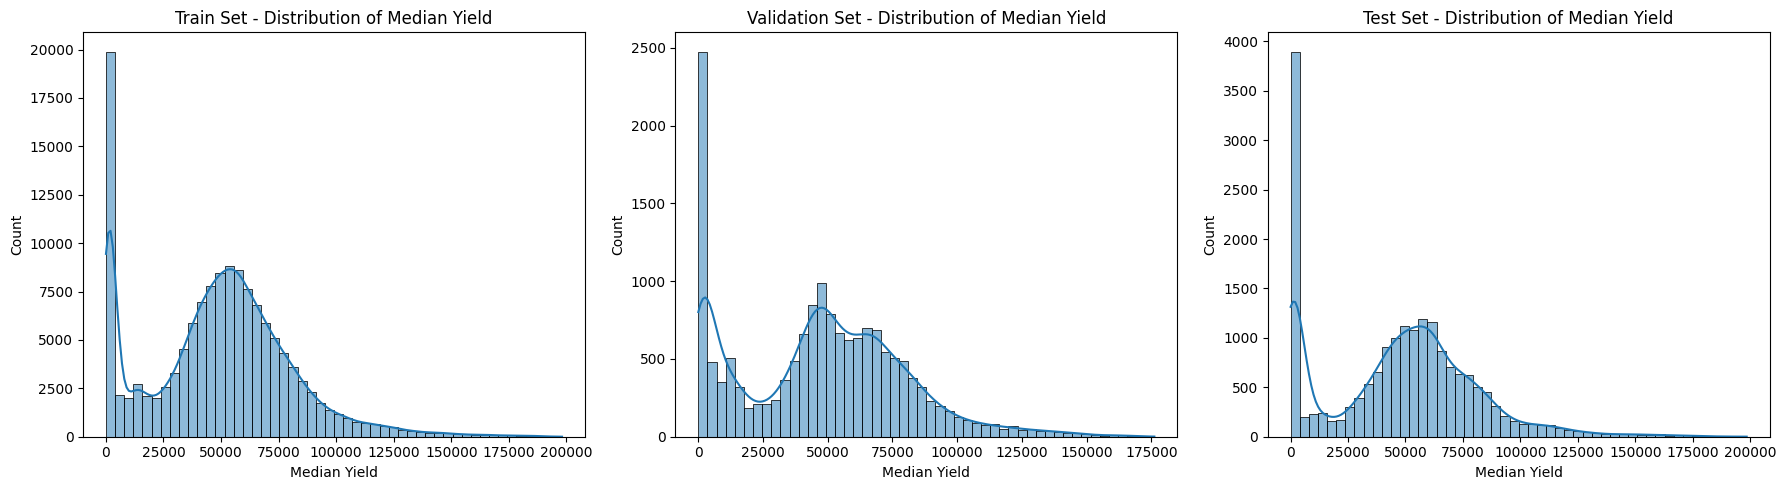

In [10]:
import seaborn as sns

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df_train, x='median_yield', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Train Set - Distribution of Median Yield')
axes[0].set_xlabel('Median Yield')
axes[0].set_ylabel('Count')

sns.histplot(data=df_val, x='median_yield', bins=50, kde=True, ax=axes[1])
axes[1].set_title('Validation Set - Distribution of Median Yield')
axes[1].set_xlabel('Median Yield')
axes[1].set_ylabel('Count')

sns.histplot(data=df_test, x='median_yield', bins=50, kde=True, ax=axes[2])
axes[2].set_title('Test Set - Distribution of Median Yield')
axes[2].set_xlabel('Median Yield')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np

up_limit = 140000
df_train[f'median_yield_clipped_{up_limit}'] = df_train['median_yield'].clip(upper=up_limit)
df_val[f'median_yield_clipped_{up_limit}'] = df_val['median_yield'].clip(upper=up_limit)
df_test[f'median_yield_clipped_{up_limit}'] = df_test['median_yield'].clip(upper=up_limit)

# Define bin ranges for median_yield
nclasses = 20
max_yield = max(df_train[f'median_yield_clipped_{up_limit}'].max(), df_val[f'median_yield_clipped_{up_limit}'].max(), df_test[f'median_yield_clipped_{up_limit}'].max())
bin_edges = np.linspace(0, max_yield, nclasses + 1)  
bin_labels_idx = list(range(len(bin_edges) - 1))
# Create string labels for the bins based on the actual bin edges
bin_labels_str = [f'{int(bin_edges[i])}-{int(bin_edges[i+1])}' for i in range(len(bin_edges) - 1)]

# Binarize train set
df_train['yield_bin'] = pd.cut(df_train[f'median_yield_clipped_{up_limit}'], bins=bin_edges, labels=bin_labels_idx, include_lowest=True)
df_train['yield_bin_range'] = pd.cut(df_train[f'median_yield_clipped_{up_limit}'], bins=bin_edges, labels=bin_labels_str, include_lowest=True)

# Binarize validation set
df_val['yield_bin'] = pd.cut(df_val[f'median_yield_clipped_{up_limit}'], bins=bin_edges, labels=bin_labels_idx, include_lowest=True)
df_val['yield_bin_range'] = pd.cut(df_val[f'median_yield_clipped_{up_limit}'], bins=bin_edges, labels=bin_labels_str, include_lowest=True)
# Binarize test set
df_test['yield_bin'] = pd.cut(df_test[f'median_yield_clipped_{up_limit}'], bins=bin_edges, labels=bin_labels_idx, include_lowest=True)
df_test['yield_bin_range'] = pd.cut(df_test[f'median_yield_clipped_{up_limit}'], bins=bin_edges, labels=bin_labels_str, include_lowest=True)

In [16]:

df_test.yield_bin.value_counts() , df_val.yield_bin.value_counts(), df_train.yield_bin.value_counts()

(yield_bin
 0     4054
 8     2084
 7     1945
 6     1727
 9     1494
 5     1292
 10    1153
 11     947
 4      808
 12     652
 3      444
 1      415
 13     357
 2      293
 19     241
 14     233
 15     214
 16     179
 17     114
 18      73
 Name: count, dtype: int64,
 yield_bin
 0     2949
 6     1801
 7     1491
 9     1384
 8     1239
 5     1115
 10    1070
 11     877
 1      853
 4      584
 12     573
 2      513
 3      406
 13     373
 14     229
 19     190
 15     166
 16     138
 17     113
 18      87
 Name: count, dtype: int64,
 yield_bin
 0     21635
 7     15391
 8     14410
 6     13750
 9     11522
 5     10759
 10     8922
 4      6787
 11     6644
 12     4483
 3      4185
 1      3973
 2      3893
 13     2869
 14     2004
 19     1797
 15     1445
 16     1171
 17      939
 18      640
 Name: count, dtype: int64)

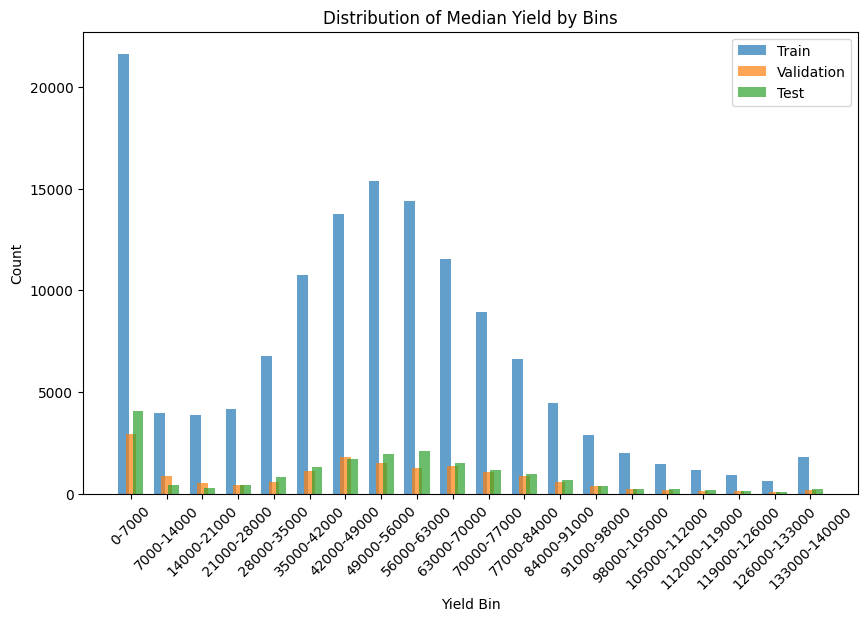

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Plot histogram using the binned data
train_counts = df_train['yield_bin'].value_counts().sort_index()
val_counts = df_val['yield_bin'].value_counts().sort_index()
test_counts = df_test['yield_bin'].value_counts().sort_index()

# Convert categorical index to numeric for plotting
train_x = range(len(train_counts))
val_x = range(len(val_counts))
test_x = range(len(test_counts))

 
plt.bar([x - 0.2 for x in train_x], train_counts.values, width=0.3, label='Train', alpha=0.7)
plt.bar(val_x, val_counts.values, width=0.3, label='Validation', alpha=0.7)
plt.bar([x + 0.2 for x in test_x], test_counts.values, width=0.3, label='Test', alpha=0.7)

plt.title('Distribution of Median Yield by Bins')
plt.xlabel('Yield Bin')
plt.ylabel('Count')
plt.legend()
plt.xticks(range(nclasses), labels=bin_labels_str if 'bin_labels_str' in locals() else range(nclasses), rotation=45)
plt.show()

In [18]:
df_train.to_parquet(f"/projects/HEScaleAgData/reference_datasets/LPIS_Extractions_2024/df_train_{woi_tag}.parquet")
df_val.to_parquet(f"/projects/HEScaleAgData/reference_datasets/LPIS_Extractions_2024/df_val_{woi_tag}.parquet")
df_test.to_parquet(f"/projects/HEScaleAgData/reference_datasets/LPIS_Extractions_2024/df_test_{woi_tag}.parquet")
